In [13]:
# Step 1:packages install
packages <- c("tidyverse", "ggplot2", "dplyr", "scales", "corrplot", "gridExtra")
new_pkgs <- packages[!(packages %in% installed.packages()[,"Package"])]
if(length(new_pkgs)) install.packages(new_pkgs, repos='https://cloud.r-project.org')

library(tidyverse)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(gridExtra)

cat("All packages successfully loaded!\n")

All packages successfully loaded!


In [14]:
# Step 2: Dataset ko direct cloud link se load kar rhe
dataset_url <- "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/employee_attrition/HR-Employee-Attrition-All.csv"
hr_data <- read.csv(dataset_url, stringsAsFactors = FALSE)

# Dataset ki dimensions (Rows x Columns)
cat("Dataset Dimensions (Rows, Columns):", dim(hr_data), "\n")

# Initial Structure aur pehle 5 rows
str(hr_data[, 1:10]) # Pehle 10 columns ka structure
head(hr_data, 5)

Dataset Dimensions (Rows, Columns): 1470 35 
'data.frame':	1470 obs. of  10 variables:
 $ Age             : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition       : chr  "Yes" "No" "Yes" "No" ...
 $ BusinessTravel  : chr  "Travel_Rarely" "Travel_Frequently" "Travel_Rarely" "Travel_Frequently" ...
 $ DailyRate       : int  1102 279 1373 1392 591 1005 1324 1358 216 1299 ...
 $ Department      : chr  "Sales" "Research & Development" "Research & Development" "Research & Development" ...
 $ DistanceFromHome: int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education       : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField  : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EmployeeCount   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ EmployeeNumber  : int  1 2 4 5 7 8 10 11 12 13 ...


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2


In [15]:
# Step 3: Missing values aur duplicates check krre
missing_vals <- colSums(is.na(hr_data))
cat("Total Missing Values in Dataset:", sum(missing_vals), "\n")
cat("Duplicate Rows:", sum(duplicated(hr_data)), "\n")

# Robust Imputation Function (Requirement #8 & #9 ke liye):
# Numeric missing values ko Median se aur Categorical ko Mode se fill karta hai
handle_missing_values <- function(data) {
  for(col_name in names(data)) {
    if(is.numeric(data[[col_name]])) {
      med_val <- median(data[[col_name]], na.rm = TRUE)
      data[[col_name]][is.na(data[[col_name]])] <- med_val
    } else {
      mode_val <- names(sort(table(data[[col_name]]), decreasing = TRUE))[1]
      data[[col_name]][is.na(data[[col_name]])] <- mode_val
    }
  }
  return(data)
}
hr_data <- handle_missing_values(hr_data)
cat("Data Quality check complete.\n")

Total Missing Values in Dataset: 0 
Duplicate Rows: 0 
Data Quality check complete.


In [16]:
# Step 4: Jin columns ki value sabhi ke liye same hai unhe drop kar rhe
# EmployeeCount (always 1), Over18 (always Y), StandardHours (always 80), EmployeeNumber (ID)
redundant_cols <- c("EmployeeCount", "Over18", "StandardHours", "EmployeeNumber")
hr_clean <- hr_data %>% dplyr::select(-all_of(redundant_cols))

cat("Dimensions after removing redundant columns:", dim(hr_clean), "\n")

Dimensions after removing redundant columns: 1470 31 


In [17]:
# Step 5: Categorical columns ko Factors me convert karna
cat_cols <- c("Attrition", "BusinessTravel", "Department", "EducationField",
              "Gender", "JobRole", "MaritalStatus", "OverTime")
hr_clean[cat_cols] <- lapply(hr_clean[cat_cols], as.factor)

# Attrition ko quantitative rate calculation ke liye Binary me encode karna (Yes=1, No=0)
hr_clean$Attrition_Num <- ifelse(hr_clean$Attrition == "Yes", 1, 0)

# Feature Engineering:
# 1. Tenure Ratio: Total career me se kitna time current company me bitaya
hr_clean$TenureRatio <- round(hr_clean$YearsAtCompany / ifelse(hr_clean$TotalWorkingYears == 0, 1, hr_clean$TotalWorkingYears), 2)

# 2. Age Group Bucketing
hr_clean$AgeGroup <- cut(hr_clean$Age,
                         breaks = c(17, 30, 45, 65),
                         labels = c("Young (<30)", "Mid-Career (30-45)", "Senior (45+)"))

# 3. Composite Total Satisfaction Score
hr_clean$TotalSatisfaction <- hr_clean$EnvironmentSatisfaction +
                              hr_clean$JobSatisfaction +
                              hr_clean$RelationshipSatisfaction

cat("Feature engineering and factor encoding complete!\n")

Feature engineering and factor encoding complete!


In [18]:
# Step 6: IQR Method se MonthlyIncome ke Outliers detect karna
Q1 <- quantile(hr_clean$MonthlyIncome, 0.25)
Q3 <- quantile(hr_clean$MonthlyIncome, 0.75)
IQR_val <- Q3 - Q1
upper_limit <- Q3 + 1.5 * IQR_val
outliers_count <- sum(hr_clean$MonthlyIncome > upper_limit)

cat("MonthlyIncome Upper IQR Limit:", upper_limit, "\n")
cat("Number of High-Income Outliers:", outliers_count, "\n")

# Winsorization (95th percentile par capping)
cap_val <- quantile(hr_clean$MonthlyIncome, 0.95)
hr_clean$MonthlyIncome_Capped <- ifelse(hr_clean$MonthlyIncome > cap_val, cap_val, hr_clean$MonthlyIncome)

# Min-Max Normalization Function [0, 1]
min_max_scale <- function(x) { (x - min(x)) / (max(x) - min(x)) }
hr_clean$Income_Normalized <- min_max_scale(hr_clean$MonthlyIncome)

# Z-Score Standardization (Mean = 0, SD = 1)
hr_clean$Income_Standardized <- as.vector(scale(hr_clean$MonthlyIncome))

cat("Outlier treatment and normalization complete!\n")

MonthlyIncome Upper IQR Limit: 16581 
Number of High-Income Outliers: 114 
Outlier treatment and normalization complete!


In [19]:
# Step 7: Summary Statistics nikalna
cat("=== OVERALL STATISTICAL SUMMARY ===\n")
summary(hr_clean %>% dplyr::select(Age, MonthlyIncome, TotalWorkingYears, YearsAtCompany, DistanceFromHome))

# Department-wise Attrition Analysis
dept_summary <- hr_clean %>%
  group_by(Department) %>%
  summarise(
    Total_Employees = n(),
    Attrition_Count = sum(Attrition_Num),
    Attrition_Rate_Pct = round(mean(Attrition_Num) * 100, 2),
    Avg_Salary = round(mean(MonthlyIncome), 2)
  )
print(dept_summary)

# OverTime-wise Attrition Analysis
ot_summary <- hr_clean %>%
  group_by(OverTime) %>%
  summarise(
    Total = n(),
    Attrition_Count = sum(Attrition_Num),
    Attrition_Rate_Pct = round(mean(Attrition_Num) * 100, 2)
  )
print(ot_summary)

=== OVERALL STATISTICAL SUMMARY ===


      Age        MonthlyIncome   TotalWorkingYears YearsAtCompany  
 Min.   :18.00   Min.   : 1009   Min.   : 0.00     Min.   : 0.000  
 1st Qu.:30.00   1st Qu.: 2911   1st Qu.: 6.00     1st Qu.: 3.000  
 Median :36.00   Median : 4919   Median :10.00     Median : 5.000  
 Mean   :36.92   Mean   : 6503   Mean   :11.28     Mean   : 7.008  
 3rd Qu.:43.00   3rd Qu.: 8379   3rd Qu.:15.00     3rd Qu.: 9.000  
 Max.   :60.00   Max.   :19999   Max.   :40.00     Max.   :40.000  
 DistanceFromHome
 Min.   : 1.000  
 1st Qu.: 2.000  
 Median : 7.000  
 Mean   : 9.193  
 3rd Qu.:14.000  
 Max.   :29.000  

# A tibble: 3 × 5
  Department       Total_Employees Attrition_Count Attrition_Rate_Pct Avg_Salary
  <fct>                      <int>           <dbl>              <dbl>      <dbl>
1 Human Resources               63              12               19.0      6655.
2 Research & Deve…             961             133               13.8      6281.
3 Sales                        446              92               20.6      6959.
# A tibble: 2 × 4
  OverTime Total Attrition_Count Attrition_Rate_Pct
  <fct>    <int>           <dbl>              <dbl>
1 No        1054             110               10.4
2 Yes        416             127               30.5


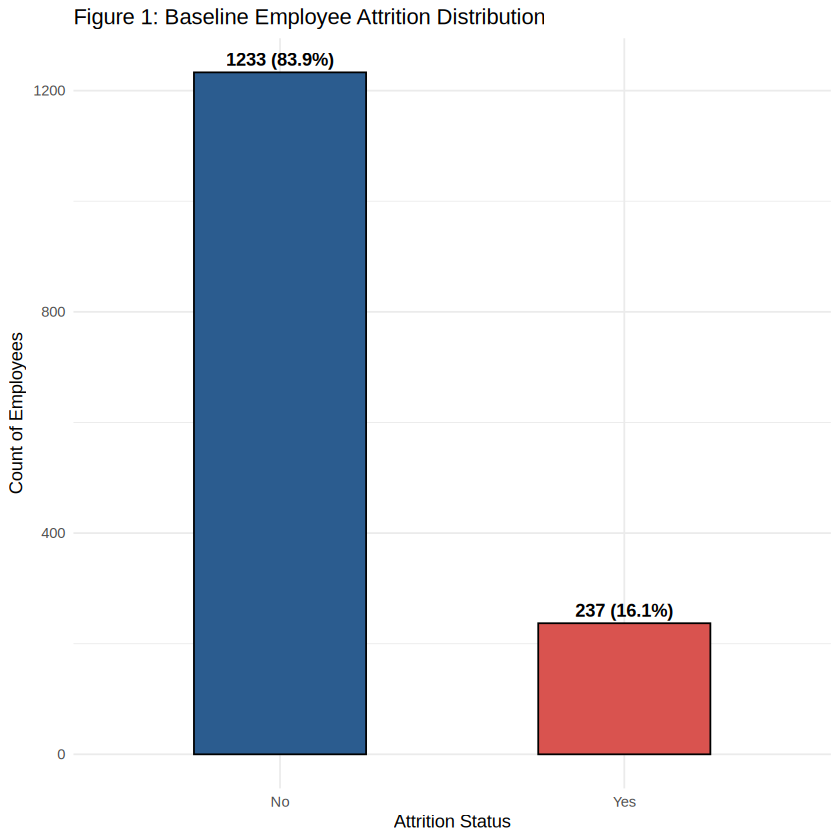

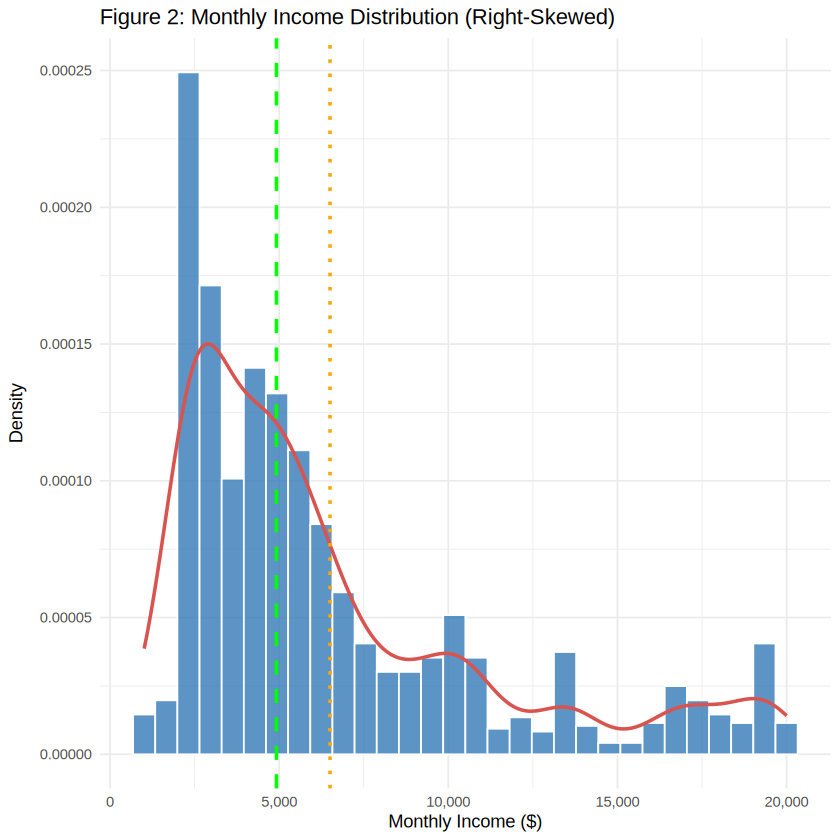

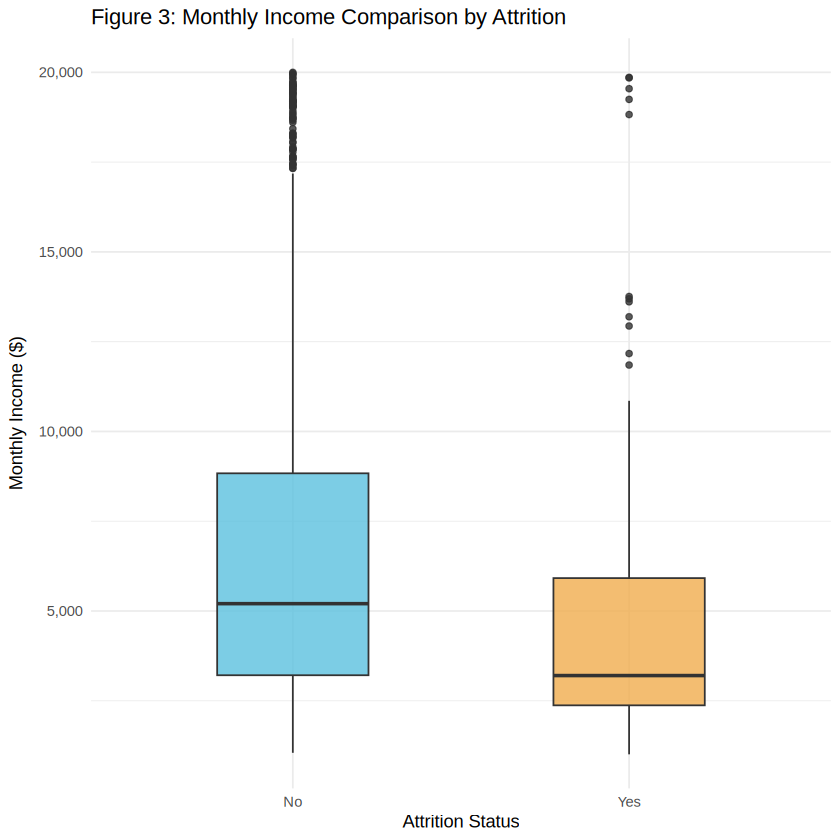

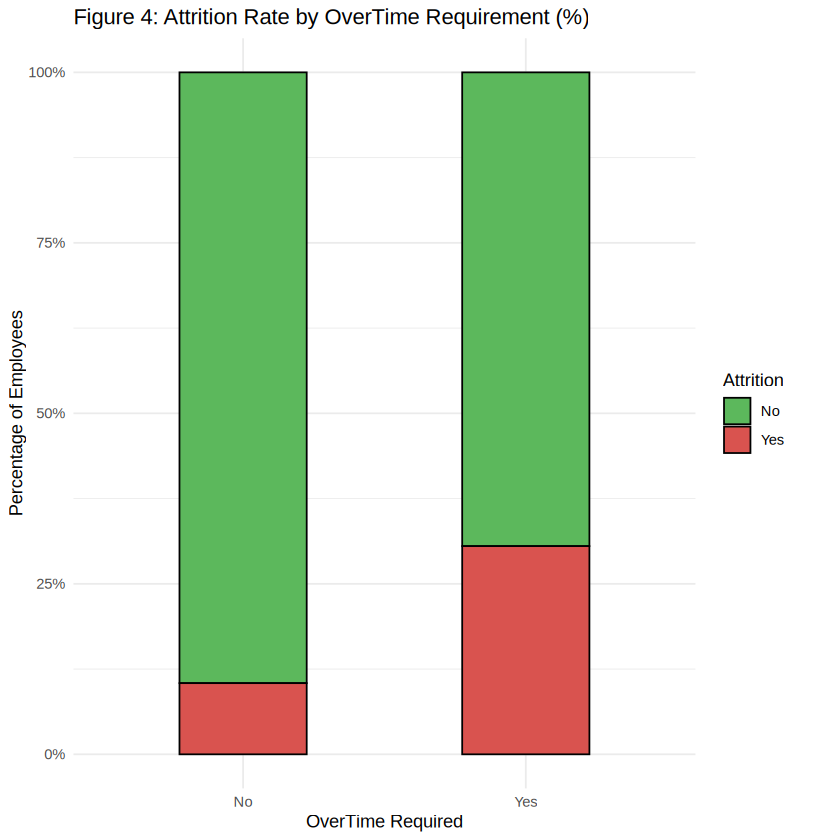

All steps executed and cleaned dataset exported!


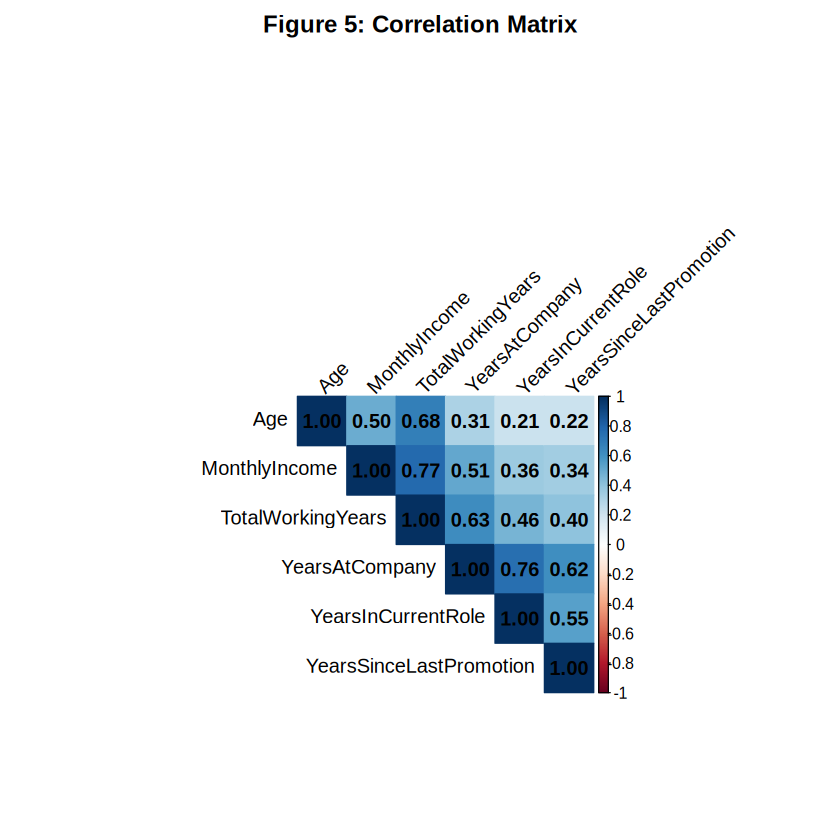

In [20]:
# Plot 1: Overall Attrition Distribution
p1 <- ggplot(hr_clean, aes(x = Attrition, fill = Attrition)) +
  geom_bar(width = 0.5, color = "black") +
  geom_text(stat = 'count', aes(label = paste0(after_stat(count), " (", round(after_stat(count)/nrow(hr_clean)*100, 1), "%)")), vjust = -0.5, fontface = "bold") +
  scale_fill_manual(values = c("No" = "#2b5c8f", "Yes" = "#d9534f")) +
  labs(title = "Figure 1: Baseline Employee Attrition Distribution", x = "Attrition Status", y = "Count of Employees") +
  theme_minimal() + theme(legend.position = "none")
print(p1)

# Plot 2: Monthly Income Distribution (Histogram + Density Curve)
p2 <- ggplot(hr_clean, aes(x = MonthlyIncome)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "#337ab7", color = "white", alpha = 0.8) +
  geom_density(color = "#d9534f", linewidth = 1) +
  geom_vline(aes(xintercept = median(MonthlyIncome)), color = "green", linetype = "dashed", linewidth = 1) +
  geom_vline(aes(xintercept = mean(MonthlyIncome)), color = "orange", linetype = "dotted", linewidth = 1) +
  scale_x_continuous(labels = comma) +
  labs(title = "Figure 2: Monthly Income Distribution (Right-Skewed)", x = "Monthly Income ($)", y = "Density") +
  theme_minimal()
print(p2)

# Plot 3: Boxplot of Income vs Attrition
p3 <- ggplot(hr_clean, aes(x = Attrition, y = MonthlyIncome, fill = Attrition)) +
  geom_boxplot(alpha = 0.8, width = 0.45) +
  scale_fill_manual(values = c("No" = "#5bc0de", "Yes" = "#f0ad4e")) +
  scale_y_continuous(labels = comma) +
  labs(title = "Figure 3: Monthly Income Comparison by Attrition", x = "Attrition Status", y = "Monthly Income ($)") +
  theme_minimal() + theme(legend.position = "none")
print(p3)

# Plot 4: Attrition Rate by OverTime
p4 <- ggplot(hr_clean, aes(x = OverTime, fill = Attrition)) +
  geom_bar(position = "fill", width = 0.45, color = "black") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("No" = "#5cb85c", "Yes" = "#d9534f")) +
  labs(title = "Figure 4: Attrition Rate by OverTime Requirement (%)", x = "OverTime Required", y = "Percentage of Employees") +
  theme_minimal()
print(p4)

# Plot 5: Correlation Heatmap of Numerical Features
num_cols <- hr_clean %>% dplyr::select(Age, MonthlyIncome, TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion)
corr_matrix <- cor(num_cols)
corrplot(corr_matrix, method = "color", addCoef.col = "black", tl.col = "black", tl.srt = 45, type = "upper", title = "Figure 5: Correlation Matrix", mar = c(0,0,2,0))

# Clean dataset export
write.csv(hr_clean, "IBM_HR_Cleaned_Dataset.csv", row.names = FALSE)
cat("All steps executed and cleaned dataset exported!\n")